In [9]:
import os
import sys
import cv2
import matplotlib.pyplot as plt

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

os.chdir('..')

# Imports from parent directory
from preprocessing import preprocess_inference
from constants import *

In [14]:
# Path to folder with input images
image_dir = './data/CowDataset/segmented_dataset/CowDataset_2'
image_paths = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png'))]

output_dir = preprocess_inference(image_paths, use_mantiuk=False, remove_background=True)
print('Segmented images saved to:', output_dir)


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.20 GiB. GPU 0 has a total capacity of 15.58 GiB of which 4.11 GiB is free. Including non-PyTorch memory, this process has 11.45 GiB memory in use. Of the allocated memory 11.11 GiB is allocated by PyTorch, and 94.29 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

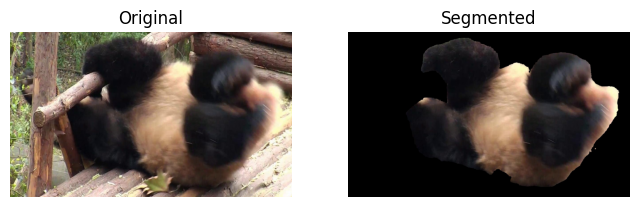

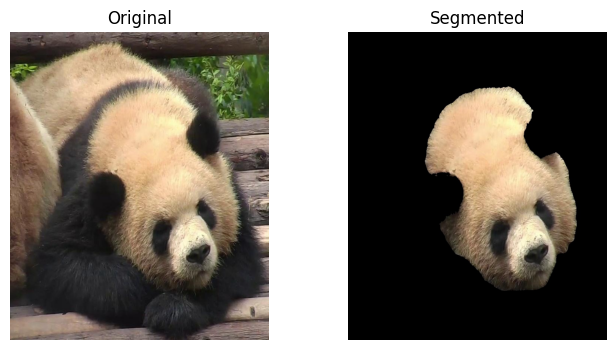

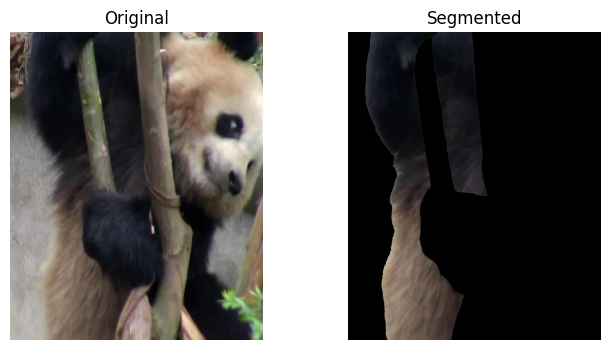

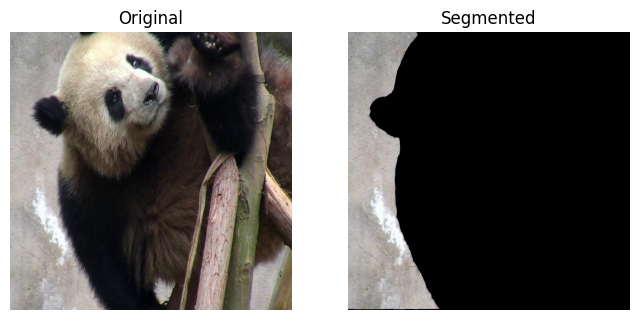

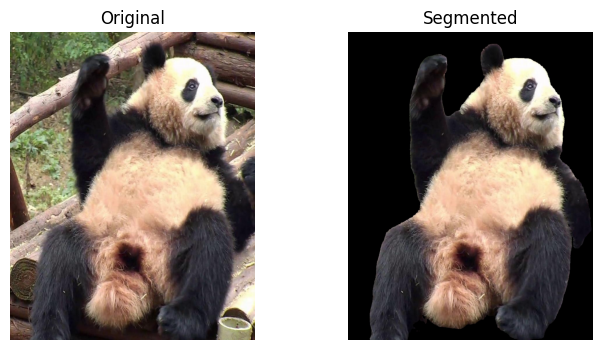

In [ ]:
# Visualize a few results
for fname in image_paths[:5]:
    name = os.path.basename(fname)
    orig = cv2.cvtColor(cv2.imread(fname), cv2.COLOR_BGR2RGB)
    seg  = cv2.cvtColor(cv2.imread(os.path.join(output_dir, name)), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(orig); plt.axis('off'); plt.title('Original')
    plt.subplot(1,2,2); plt.imshow(seg); plt.axis('off'); plt.title('Segmented')
    plt.show()
